<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/healthcare/G5_EGG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tasks
1- Creare simple code that uploads and plots the signal to see
499 Rows - Spectrum  

plot the first row all the observation


In [4]:
from google.colab import drive
drive.flush_and_unmount()

Drive not mounted, so nothing to flush and unmount.


In [5]:
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os
os.chdir("/content/drive/MyDrive/Healthcare")

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

In [8]:
df = pd.read_excel('EEG-data.xlsx')

In [9]:
# convert the dataset to Dataframe
pdf = pd.DataFrame(df)

In [10]:
egg_list = df.to_numpy()

In [11]:
pdf.head(10)

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X4086,X4087,X4088,X4089,X4090,X4091,X4092,X4093,X4094,y
0,0,-56,-50,-64,-91,-135,-140,-134,-114,-115,...,-37,-43,-63,-82,-114,-138,-159,-172,-180,5
1,1,14,25,31,36,33,33,27,27,21,...,-45,-32,-6,-7,-2,-20,-34,-40,-40,5
2,2,-159,-176,-174,-145,-101,-45,0,29,15,...,-40,-25,14,56,73,48,-12,-62,-100,4
3,3,34,31,29,19,16,12,3,-1,-5,...,-34,-33,-29,-22,-18,-14,-10,-9,0,3
4,4,44,50,46,43,43,46,45,40,36,...,4,5,6,6,2,1,0,-1,-4,2
5,5,142,262,382,451,452,435,544,562,462,...,164,-2,-118,-223,-304,-350,-339,-299,-253,1
6,6,-64,-72,-52,-24,4,21,18,-16,-53,...,-90,-85,-66,-42,-26,-10,-1,-12,-16,5
7,7,-55,-48,-48,-38,-23,0,11,22,21,...,51,61,64,42,-1,-53,-79,-93,-95,4
8,8,18,14,13,9,-6,-20,-31,-27,-10,...,-17,-3,9,25,49,63,82,96,102,4
9,9,50,48,45,41,47,51,53,40,37,...,-16,-30,-47,-63,-63,-50,-39,-25,-19,3


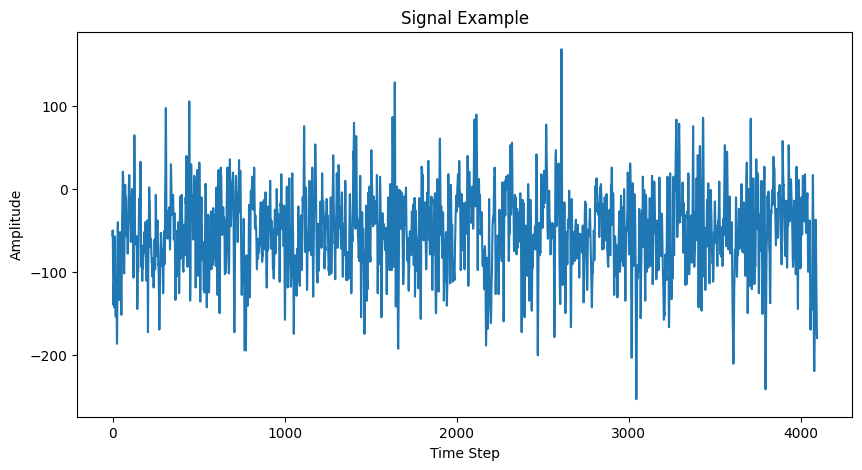

In [12]:
signal = egg_list[0, 1:-1]

plt.figure(figsize=(10,5))
plt.plot(signal)
plt.title("Signal Example")
plt.xlabel("Time Step")
plt.ylabel("Amplitude")
plt.show()

### First 5 classes

### Plot the first 2nd Class

### Find all the subject of level 2, 3 in the dataset  
### get insidght only the passient level 2 vs 3
### Readeing atutomatically classified without level to inform the parrent which level the
### Find the training and testing dataset
### Find the outlyier
### Characterized the dataset
### Training the model
### ===> 26th of the March both random forrest &

In [13]:
# Find all the subject of level 2, 3 in the dataset
# c2 =[]
# c3 =[]
# # y2 = []
# # y3 = []
# for row in egg_list:
#   if(row[-1] == 2):
#     c2.append(row[:-1])
#   if(row[-1] == 3):
#     c3.append(row[:-1])


# remove index and label
c2 = []
c3 = []

for i in egg_list:
    if i[-1] == 2:
        c2.append(i[1:-1])

    if i[-1] == 3:
        c3.append(i[1:-1])


In [22]:
# Superate the dataset for training(80%) and test dataset(20%)

split_c2 = int(0.8 * len(c2))
split_c3 = int(0.8 * len(c3))

train_c2 = c2[:split_c2]
test_c2 = c2[split_c2:]

train_c3 = c3[:split_c3]
test_c3 = c3[split_c3:]


# c2 = np.array(c2)
# c3 = np.array(c3)
# train_c2 = c2[:80, :]
# train_c3 = c3[:80, :]
# test_c2 = c2[-20:, :]
# test_c3 = c3[-20:, :]

In [23]:
# The mean value of the training dataset for class 2
c2_mean = np.mean(train_c2, axis=0)
c2_mean

array([ 0.1875, -0.6125, -0.05  , ..., -7.025 , -5.2625, -5.75  ])

# Normalization using z-transformation

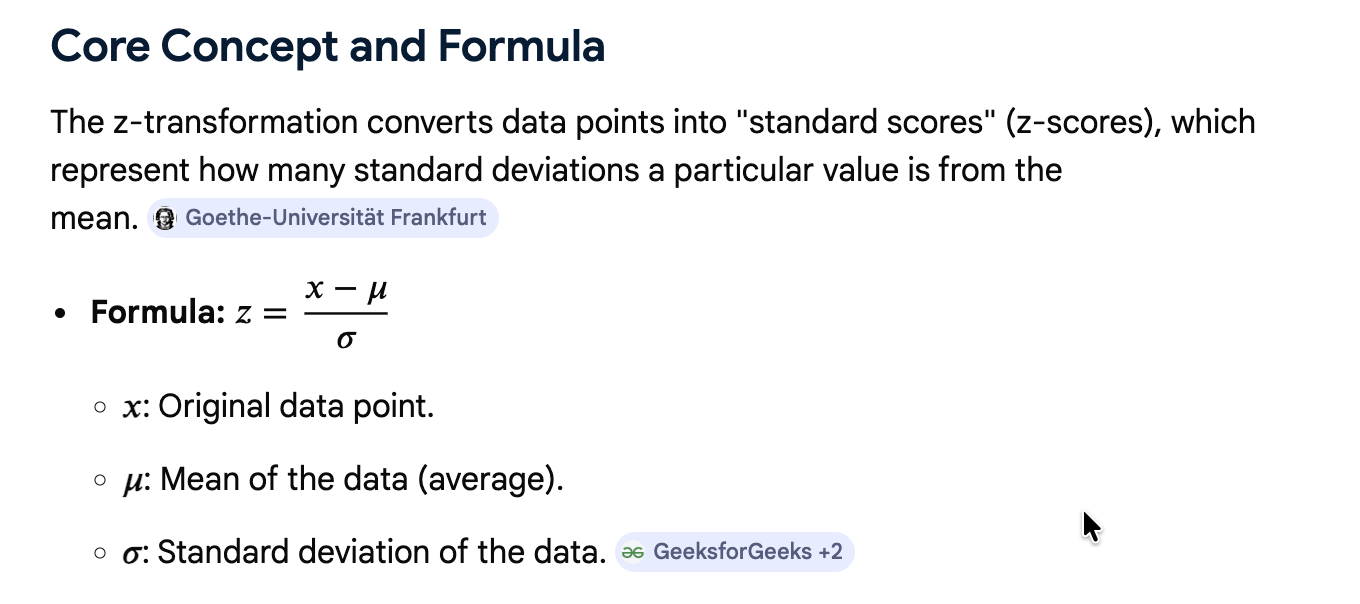



## Task 2

1. **Normalize training & testing signals to the range [0, 1] and plot them.**

2. **Compute the mean and standard deviation of the normalized data.**

3. **Plot the mean of the normalized dataset.**

4. **Identify potential outlier signals**, defined as signals that lie outside the mean ± standard deviation, and plot them

5. **Compute the distance of each signal from the mean in terms of standard deviation.**

6. **Classify a signal as an outlier if its distance is greater than a chosen threshold.** The threshold can be set to 1 or any other value depending on the analysis.


### 1. Normalize training & testing signals of class 2 & 3 and plot them.

In [37]:
# ===== Class 2 =====
# Compute mean & std from training data
mean_c2 = np.mean(train_c2)
std_c2  = np.std(train_c2)

# Normalize using training statistics
c2_training_norm = (train_c2 - mean_c2) / std_c2
c2_testing_norm  = (test_c2  - mean_c2) / std_c2

# ===== Class 3 =====
# Compute mean & std from training data
mean_c3 = np.mean(train_c3)
std_c3  = np.std(train_c3)

# Normalize using training statistics
c3_training_norm = (train_c3 - mean_c3) / std_c3
c3_testing_norm  = (test_c3  - mean_c3) / std_c3

# ===== Print the results =====
print("===== Class 2 =====")
print("Training Mean:", np.mean(c2_training_norm))
print("Training Std: ", np.std(c2_training_norm))
print("Testing  Mean:", np.mean(c2_testing_norm))
print("Testing  Std: ", np.std(c2_testing_norm))

print("\n===== Class 3 =====")
print("Training Mean:", np.mean(c3_training_norm))
print("Training Std: ", np.std(c3_training_norm))
print("Testing  Mean:", np.mean(c3_testing_norm))
print("Testing  Std: ", np.std(c3_testing_norm))

===== Class 2 =====
Training Mean: -2.7769134763462636e-18
Training Std:  1.0000000000000002
Testing  Mean: 0.08490925017165257
Testing  Std:  0.9477577240632586

===== Class 3 =====
Training Mean: -2.4992221287116372e-17
Training Std:  1.0
Testing  Mean: -0.14553731506499612
Testing  Std:  1.3739462676975052


**Plot the normalized dataset**

<Figure size 1800x1000 with 0 Axes>

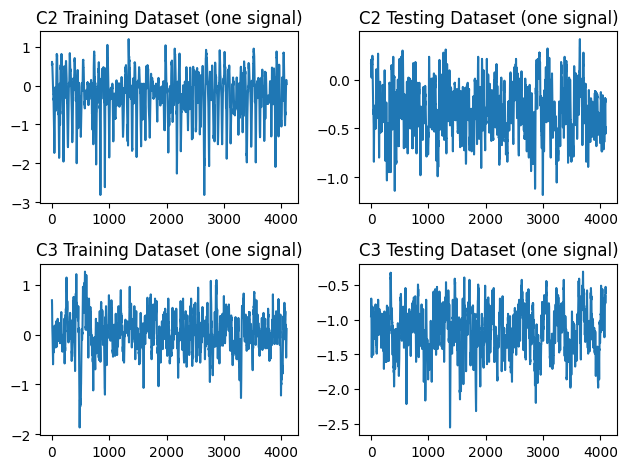

In [38]:
plt.figure(figsize=(18, 10))
fig, axes = plt.subplots(nrows=2, ncols=2)
axes = axes.flatten()

# Plot first signal from each dataset
axes[0].plot(c2_training_norm[0], label="C2 Training Signal 0")
axes[0].set_title("C2 Training Dataset (one signal)")
axes[1].plot(c2_testing_norm[0], label="C2 Testing Signal 0")
axes[1].set_title("C2 Testing Dataset (one signal)")
axes[2].plot(c3_training_norm[0], label="C3 Training Signal 0")
axes[2].set_title("C3 Training Dataset (one signal)")
axes[3].plot(c3_testing_norm[0], label="C3 Testing Signal 0")
axes[3].set_title("C3 Testing Dataset (one signal)")

fig.tight_layout()
plt.show()

### 3. Plot the mean & standard deviation of the normalized dataset.

### 4. **Identify potential outlier signals**, defined as signals that lie outside the mean ± standard deviation, and plot them
https://kmr-gautam2893.medium.com/how-to-identify-the-outliers-in-your-data-ee9c28b42fc3

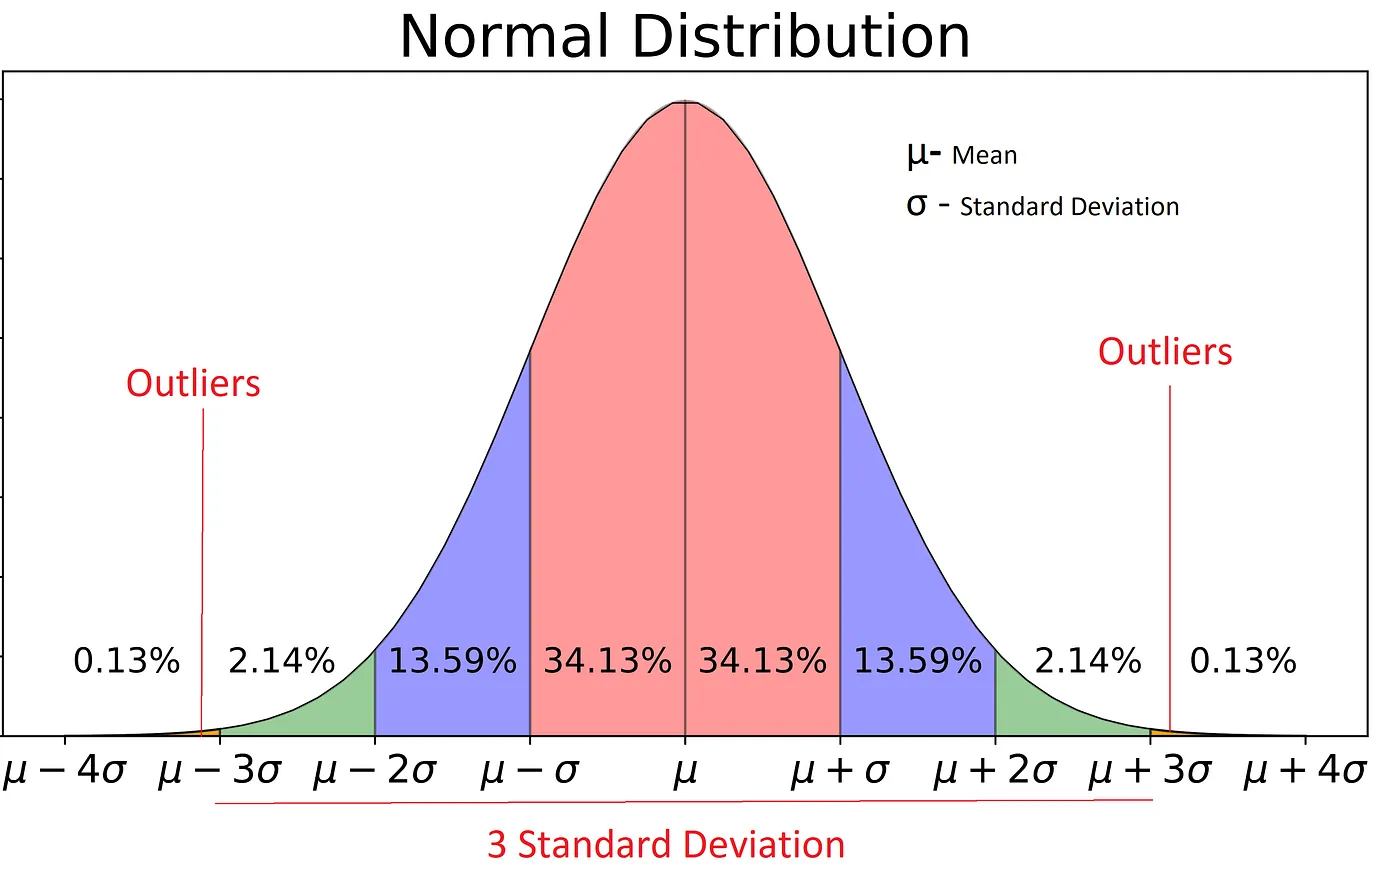

In [43]:
# 1. Get the outliers
threshold = 2
# 1.1 get the training outliers
c2_training_outliers = c2_training_norm[(c2_training_norm<-threshold) | (c2_training_norm>threshold)]
c3_training_outliers = c3_training_norm[(c3_training_norm<-threshold) | (c3_training_norm>threshold)]
# 1.2 get the testing outliers
c2_testing_outliers = c2_testing_norm[(c2_testing_norm<-threshold) | (c2_testing_norm>threshold)]
c3_testing_outliers = c3_testing_norm[(c3_testing_norm<-threshold) | (c3_testing_norm>threshold)]

In [ ]:
# # 1. Plot
# plt.figure(figsize=(15, 8))
# fig, axes = plt.subplots(nrows=2, ncols=2)
# axes = axes.flatten()
# axes[0].plot(c2_training_outliers, 'r-', label="C2 Training Outlier")
# axes[0].set_title("C2 Training Outlier")
# axes[1].plot(c2_testing_outliers, 'g-', label="C2 Testing Outlier")
# axes[1].set_title("C2 Testing Outlier")
# axes[2].plot(c3_training_outliers ,'r-' , label="C3 Training Outlier")
# axes[2].set_title("C3 Training Outlier")
# axes[3].plot(c3_testing_outliers, 'g-' , label="C3 Testing Outlier")
# axes[3].set_title("C3 Testing Outlier")
# fig.tight_layout()


plt.figure(figsize=(15,8))
plt.plot(c2_training_norm[0:3], label="C2 Training Signal 0")
outlier_mask = (c2_training_norm[0] > 2) | (c2_training_norm[0] < -2)
plt.plot(np.where(outlier_mask)[0], c2_training_norm[0][outlier_mask], 'ro', label="Outliers")
plt.title("C2 Training Signal 0 with Outliers")
plt.legend()
plt.show()

## Train a linear kernel SVM classifier using 80% of the dataset containing the outlier and evaluate its performance. Then remove the outlier, repeat the 80/20 training–testing process, and compare the results.

In [ ]:
# define the model
svm_model = SVC(C=1.0, kernel="linear", random_state=42)

In [ ]:
# find label for class 2 & 3
train_label2 = np.zeros(len(c2_training_norm))
train_label3 = np.ones(len(c3_training_norm))
test_label2 = np.zeros(len(c2_testing_norm))
test_label3 = np.ones(len(c3_testing_norm))

In [ ]:
# Prepare the trianing and testing dataset
final_train = np.vstack((c2_training_norm, c3_training_norm))
final_test = np.vstack((c2_testing_norm, c3_testing_norm))
final_train.shape, final_test.shape

((160, 4094), (40, 4094))

In [ ]:
# get the classes
final_y_train = np.hstack((train_label2, train_label3))
final_y_test = np.hstack((test_label2, test_label3))
final_y_train.shape, final_y_test.shape

((160,), (40,))

In [ ]:
# Fit the model on 80% of dataset with outlier
svm_model.fit(X=final_train, y=final_y_train.ravel())

SVC(kernel='linear', random_state=42)

In [ ]:
# Predict the model on the testing dataset
y_pred_1 = svm_model.predict(final_test)
y_pred_1

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 0., 1.,
       0., 1., 1., 0., 1., 0.])

In [ ]:
# Get the accuracy score
accuracy1 = accuracy_score(y_true=final_y_test.ravel(), y_pred=y_pred_1)
accuracy1

0.875

## Train a linear kernel SVM classifier using 80% of the dataset **without** the outlier and evaluate its performance, and compare the results.

 Now We have to superate the dataset from outliers
**Remove the outlier**


In [ ]:
threshold = 3
# 1. Cobine the two dataset c2 & c3
X = np.vstack(((c2-np.mean(c2))/np.std(c2), (c3-np.mean(c3))/np.std(c3)))
# 2. Create labels
y = np.hstack((np.zeros(len(c2)), np.ones(len(c3))))
# 3. Detect outlier
mask = np.all((X<threshold) & (X>-threshold), axis=1)
# 4. Remove outlier form X & y
X_clean = X[mask]
y_clean = y[mask]

Split the Training and Testing data 80% training & 20% testing

In [ ]:
# 1. split training data
X_train = X_clean[:80]
y_train = y_clean[:80]
#2. split testing data
X_test = X_clean[20:]
y_test = y_clean[20:]

In [ ]:
X_train.shape, y_train.shape

((60, 4095), (60,))

In [ ]:
svm_model.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [ ]:
y_pred = svm_model.predict(X_test)
y_pred

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1.])

In [ ]:
accuracy_score2 = accuracy_score(y_true=y_test, y_pred=y_pred)
accuracy_score2

1.0